In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Found 622 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 512)                 │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,981,444 (57.15 MB)

 Trainable params: 265,732 (1.01 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5896 - loss: 0.8918
Epoch 1: val_loss improved from inf to 1.23281, saving model to ./vgg16_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 309ms/step - accuracy: 0.5924 - loss: 0.8868 - val_accuracy: 0.5278 - val_loss: 1.2328 - learning_rate: 0.0010
Epoch 2/100


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Epoch 2: val_loss improved from 1.23281 to 1.23280, saving model to ./vgg16_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5278 - val_loss: 1.2328 - learning_rate: 0.0010
Epoch 3/100
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9068 - loss: 0.2515
Epoch 3: val_loss did not improve from 1.23280
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.9075 - loss: 0.2510 - val_accuracy: 0.3611 - val_loss: 1.2403 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: val_loss did not improve from 1.23280
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.3611 - val_loss: 1.2403 - learning_rate: 0.0010
Epoch 5/100
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9761 - loss: 0.1348
Epoch 5: val_loss improved from 1.23280 to 1.20228, saving model to ./vgg16_model.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.9761 - loss: 0.1342 - val_accuracy: 0.3611 - val_

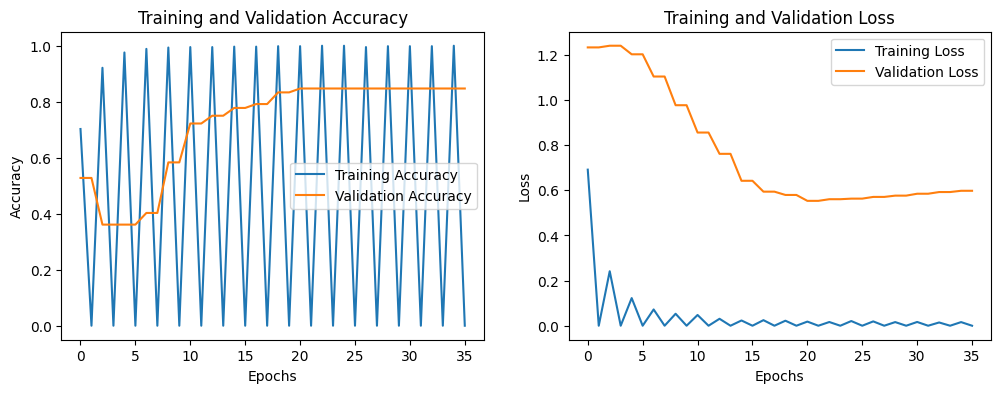

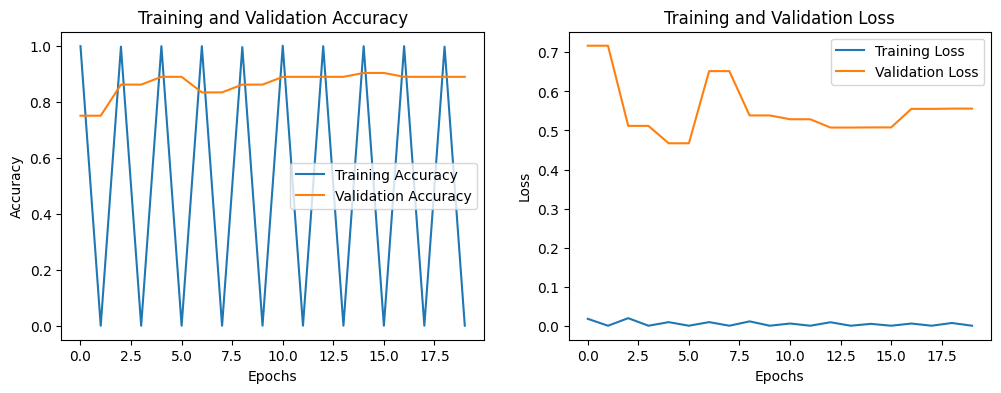

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

train_dir = '/content/drive/MyDrive/LungCancer/Data/train'
valid_dir = '/content/drive/MyDrive/LungCancer/Data/valid'
test_dir = '/content/drive/MyDrive/LungCancer/Data/test'



image_shape = (224, 224, 3)
N_CLASSES = 4
BATCH_SIZE = 16
train_datagen = ImageDataGenerator(dtype='float32', rescale=1.0 / 255.0)
valid_datagen = ImageDataGenerator(dtype='float32', rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(dtype='float32', rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir, batch_size=BATCH_SIZE, target_size=image_shape[:2], class_mode='categorical'
)
valid_generator = valid_datagen.flow_from_directory(
    valid_dir, batch_size=BATCH_SIZE, target_size=image_shape[:2], class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_dir, batch_size=BATCH_SIZE, target_size=image_shape[:2], class_mode='categorical'
)

vgg_model = VGG16(include_top=False, pooling='avg', weights='imagenet', input_shape=image_shape)
for layer in vgg_model.layers:
    layer.trainable = False

model = Sequential([
    vgg_model,
    Flatten(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dense(N_CLASSES, activation='softmax')
])
model.summary()

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

checkpointer = ModelCheckpoint(
    filepath='./vgg16_model.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True
)
early_stopping = EarlyStopping(verbose=1, patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Learning Rate Scheduler function
def scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch < 20:
        return lr * 0.9  # Gradually reduce by 10%
    else:
        return lr * 0.8  # Gradual reduction

lr_scheduler = LearningRateScheduler(scheduler)

history_vgg = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=valid_generator,
    callbacks=[checkpointer, early_stopping, reduce_lr, lr_scheduler],
    verbose=1
)


for layer in vgg_model.layers[-4:]:  # Unfreeze last few layers
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=valid_generator,
    callbacks=[checkpointer, early_stopping, reduce_lr],
    verbose=1
)

def plot_training(history):
    plt.figure(figsize=(12, 4))
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.show()

plot_training(history_vgg)
plot_training(history_finetune)

In [ ]:
import os

# Desired directory to save the model
save_dir = '/content/drive/MyDrive/lungcancer/saved_models'

# Create the directory if it does not exist
os.makedirs(save_dir, exist_ok=True)

# Save the model in Keras format
keras_model_path = os.path.join(save_dir, 'vgg16_model.keras')
model.save(keras_model_path)
print(f"Model saved in Keras format at: {keras_model_path}")

# Save the model in HDF5 format
h5_model_path = os.path.join(save_dir, 'vgg16_model.h5')
model.save(h5_model_path)
print(f"Model saved in HDF5 format at: {h5_model_path}")

# Save the model in TensorFlow SavedModel format using `export`
saved_model_dir = os.path.join(save_dir, 'saved_model/vgg16_model')
model.export(saved_model_dir)  # Use `export()` for SavedModel format
print(f"Model exported in TensorFlow SavedModel format at: {saved_model_dir}")


Model saved in Keras format at: /content/drive/MyDrive/lungcancer/saved_models/vgg16_model.keras
Model saved in HDF5 format at: /content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5
Saved artifact at '/content/drive/MyDrive/lungcancer/saved_models/saved_model/vgg16_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float16, name='keras_tensor_322')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float16, name=None)
Captures:
  135466902460496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466902713472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466902713648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135467937948496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466902114320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466899539040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466899552944: TensorSpec(shape=(), dtype=tf

In [ ]:
from tensorflow.keras.models import load_model

# Load the model saved in .keras format
loaded_model_keras = load_model('vgg16_model.keras')
test_loss, test_accuracy = loaded_model_keras.evaluate(test_generator)
print(f"\nTest Accuracy (Keras format): {test_accuracy * 100:.2f}%")



/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 268ms/step - accuracy: 0.8763 - loss: 0.4607

Test Accuracy (Keras format): 89.21%


In [ ]:
import os

save_dir = '/content/drive/MyDrive/lungcancer/saved_models'
os.makedirs(save_dir, exist_ok=True)

keras_model_path = os.path.join(save_dir, 'vgg16_model.keras')
model.save(keras_model_path)
print(f"Model saved in Keras format at: {keras_model_path}")
h5_model_path = os.path.join(save_dir, 'vgg16_model.h5')
model.save(h5_model_path)
print(f"Model saved in HDF5 format at: {h5_model_path}")

saved_model_dir = os.path.join(save_dir, 'saved_model/vgg16_model')
model.export(saved_model_dir)
print(f"Model exported in TensorFlow SavedModel format at: {saved_model_dir}")
model.save("/content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5")


Model saved in Keras format at: /content/drive/MyDrive/lungcancer/saved_models/vgg16_model.keras
Model saved in HDF5 format at: /content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5
Saved artifact at '/content/drive/MyDrive/lungcancer/saved_models/saved_model/vgg16_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float16, name='keras_tensor_322')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float16, name=None)
Captures:
  135466902460496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466902713472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466902713648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135467937948496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466902114320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466899539040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135466899552944: TensorSpec(shape=(), dtype=tf